# 034 自适应优化器与权重衰减

重启内核，从首格顺序执行。沿同一两行九参数网络完成两次Adam计算，再查看解耦机制和完整等预算搜索。先读lecture.pdf与lab.pdf。输出是CPU合成实验，不是普遍优化器排名。

In [1]:
from pathlib import Path
import hashlib, json, tempfile, csv, io
ROOT = Path.cwd()
EXPECTED = {'data/config.json': '44a32083abe6111dd15cb923e1af6c68b93bed4adbf44dcfe2ca779cf186f8d0', 'data/hand-example.json': 'ab398e1c13115642372e5994c6787ad07a07058cae720a472f592308a0b50c89', 'data/samples.csv': '482391854b087c4d063921bae01af4ed2f11c83f19bb2b19c3a36d7a8874671c', 'outputs/hand-trace.json': '80bbb9e8ef1f55f0d59ed8e9c16a6826032e2f6d9c710b7281eb6a4661eb5e18', 'outputs/mechanisms.json': '8443486a5121c76c39e726b53cdafda0b188ae3ffc71bf044f3e84a5a56c72eb', 'outputs/search-grid.csv': '98cec881d02bc18018c1412b6bf01115c1fdc58d0c7897c6f7e4ddee9ab8d07f', 'outputs/selected-trajectories.json': 'de1afecdf7cb8fa6b38c85ea7ce32f75301fd469a85a6ab0a2936a2375510208', 'outputs/selection.json': '99b668a94ea355e2ab011a05cfbb2fd113fe33c6dec178276dffd591ce949938', 'outputs/state-check.json': '4846650dd4217a86f67f2b6e6bd93433a8f567709724e4e80bc4725873658d69', 'outputs/summary.json': 'bda90706a1a8c5a84bb14292eb17ecb5fdfc4b5072a3fa691011be014d18c47e', 'outputs/test-report.json': 'f50a19c5e11eeb9e9cda5e62c58fb3002fc94197a94b633758285876ed363962', 'figures/03_coordinate_steps.png': '907569d5e9f6f594e3d7d6085df6a163694632ef2ab40d02fb8c818a105c8c2d', 'figures/07_search_grid.png': '9424d08640745ef5186cef7bb46b2c97d38234a310a8d823a16ddd2be16233bc', 'figures/09_test_and_state.png': '67024b4b224bb86ff8baf4748e789a5877df4a05db9508c1efd81c1c7b5a85bd'}
for name, sha in EXPECTED.items():
    if hashlib.sha256((ROOT / name).read_bytes()).hexdigest() != sha:
        raise ValueError("Fixed teaching input/report changed: " + name)
import numpy as np
import torch
import experiment as e
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
print("CPU", torch.__version__, "NumPy", np.__version__)

CPU 2.7.1+cpu NumPy 2.3.5


## 从数据出发
X按行存两条样本，W的行是输入坐标、列是隐藏坐标；这里没有把转置约定藏进层对象。输出权重在代码中叫v1/v2，与Adam二阶状态v不同。

In [2]:
cfg, hand, data = e.load_inputs()
print("hand inputs", hand)
print("split sizes", {k: len(v["X"]) for k, v in data.items()})
trace = e.hand_trace(hand)
print("parameter order", trace["parameter_order"])

hand inputs {'X': [[1, 2], [-1, 1]], 'y': [[0.7], [-0.2]], 'theta': [0.5, -0.2, 0.3, 0.4, 0.1, 0.2, 0.6, -0.5, 0.1], 'lr': 0.02, 'betas': [0.8, 0.9], 'eps': 0.001, 'steps': 2}
split sizes {'train': 48, 'validation': 16, 'test': 16}


parameter order ['W11', 'W12', 'W21', 'W22', 'b1', 'b2', 'v1', 'v2', 'c']


In [3]:
first = trace["steps"][0]["forward_backward"]
for key in ["shapes", "Z", "H", "P", "residual", "sample_half_squared_error", "loss"]:
    print(key, first[key])

shapes {'X': [2, 2], 'W': [2, 2], 'b': [2], 'Z': [2, 2], 'H': [2, 2], 'v': [2, 1], 'c': [], 'P': [2, 1], 'contributions': [2, 9]}
Z [[ 1.2  0.8]
 [-0.1  0.8]]
H [[1.2 0.8]
 [0.  0.8]]
P [[ 0.42]
 [-0.3 ]]
residual [[-0.28]
 [-0.1 ]]
sample_half_squared_error [0.0392 0.005 ]
loss 0.02209999999999999


## 第1次局部导数与两条样本路径
先从平均半平方误差得到dP；再乘输出权重、ReLU掩码。每个参数的两行贡献必须求和，不能误删样本2的全部贡献。

In [4]:
for key, value in first["local"].items():
    print("local", key, value)
for key, value in first["chain"].items():
    print("chain", key, value)
print("two-sample parameter contributions")
print(first["contributions"])
print("summed gradients", first["gradient"])

local dL_dsample_loss [0.5, 0.5]
local dsample_loss_dP [[-0.28]
 [-0.1 ]]
local dP_dH [[ 0.6 -0.5]
 [ 0.6 -0.5]]
local dP_dv [[1.2 0.8]
 [0.  0.8]]
local dP_dc [1.0, 1.0]
local dH_dZ [[1. 1.]
 [0. 1.]]
local dZ_dW [[ 1.  2.]
 [-1.  1.]]
local dZ_db [[1. 1.]
 [1. 1.]]
chain dL_dP [[-0.14]
 [-0.05]]
chain dL_dH [[-0.084  0.07 ]
 [-0.03   0.025]]
chain dL_dZ [[-0.084  0.07 ]
 [-0.     0.025]]
chain dL_dX [[-0.056   0.0028]
 [-0.005   0.01  ]]
two-sample parameter contributions
[[-0.084  0.07  -0.168  0.14  -0.084  0.07  -0.168 -0.112 -0.14 ]
 [ 0.    -0.025  0.     0.025 -0.     0.025 -0.    -0.04  -0.05 ]]
summed gradients [-0.084  0.045 -0.168  0.165 -0.084  0.095 -0.168 -0.152 -0.19 ]


In [5]:
a = trace["steps"][0]["adam"]
for key in ["m", "v", "m_hat", "v_hat", "denominator", "adaptive_delta", "theta_after"]:
    print(key, a[key])
print("next forward", trace["steps"][0]["next_forward"])

m [-0.0168  0.009  -0.0336  0.033  -0.0168  0.019  -0.0336 -0.0304 -0.038 ]
v [0.0007056 0.0002025 0.0028224 0.0027225 0.0007056 0.0009025 0.0028224
 0.0023104 0.00361  ]
m_hat [-0.084  0.045 -0.168  0.165 -0.084  0.095 -0.168 -0.152 -0.19 ]
v_hat [0.007056 0.002025 0.028224 0.027225 0.007056 0.009025 0.028224 0.023104
 0.0361  ]
denominator [0.085 0.046 0.169 0.166 0.085 0.096 0.169 0.153 0.191]
adaptive_delta [ 0.01976471 -0.01956522  0.01988166 -0.01987952  0.01976471 -0.01979167
  0.01988166  0.01986928  0.01989529]
theta_after [ 0.51976471 -0.21956522  0.31988166  0.38012048  0.11976471  0.18020833
  0.61988166 -0.48013072  0.11989529]
next forward {'Z': array([[ 1.27929273,  0.72088408],
       [-0.08011834,  0.77989403]]), 'H': array([[1.27929273, 0.72088408],
       [0.        , 0.77989403]]), 'P': array([[ 0.56678679],
       [-0.25455579]]), 'residual': array([[-0.13321321],
       [-0.05455579]]), 'sample_half_squared_error': array([0.00887288, 0.00148817]), 'loss': 0.005180

## 第2次须重新前向 反向 并保留状态
把下面所有中间量与正文第4.5至4.8节对齐。不是只调用一次optimizer.step然后看最终损失。

In [6]:
second = trace["steps"][1]
for key in ["Z", "H", "P", "residual", "loss", "local", "chain", "contributions", "gradient"]:
    print(key, second["forward_backward"][key])
for key in ["m_before", "v_before", "m", "v", "m_hat", "v_hat", "denominator", "theta_after"]:
    print(key, second["adam"][key])
print("third forward", second["next_forward"])

Z [[ 1.27929273  0.72088408]
 [-0.08011834  0.77989403]]
H [[1.27929273 0.72088408]
 [0.         0.77989403]]
P [[ 0.56678679]
 [-0.25455579]]
residual [[-0.13321321]
 [-0.05455579]]
loss 0.005180523473031142
local {'dL_dsample_loss': [0.5, 0.5], 'dsample_loss_dP': array([[-0.13321321],
       [-0.05455579]]), 'dP_dH': array([[ 0.61988166, -0.48013072],
       [ 0.61988166, -0.48013072]]), 'dP_dv': array([[1.27929273, 0.72088408],
       [0.        , 0.77989403]]), 'dP_dc': [1.0, 1.0], 'dH_dZ': array([[1., 1.],
       [0., 1.]]), 'dZ_dW': array([[ 1.,  2.],
       [-1.,  1.]]), 'dZ_db': array([[1., 1.],
       [1., 1.]])}
chain {'dL_dP': array([[-0.0666066],
       [-0.0272779]]), 'dL_dH': array([[-0.04128821,  0.03197988],
       [-0.01690907,  0.01309696]]), 'dL_dZ': array([[-0.04128821,  0.03197988],
       [-0.        ,  0.01309696]]), 'dL_dX': array([[-0.02848182, -0.00105114],
       [-0.00287564,  0.00497842]])}
contributions [[-0.04128821  0.03197988 -0.08257642  0.06395975 -0.

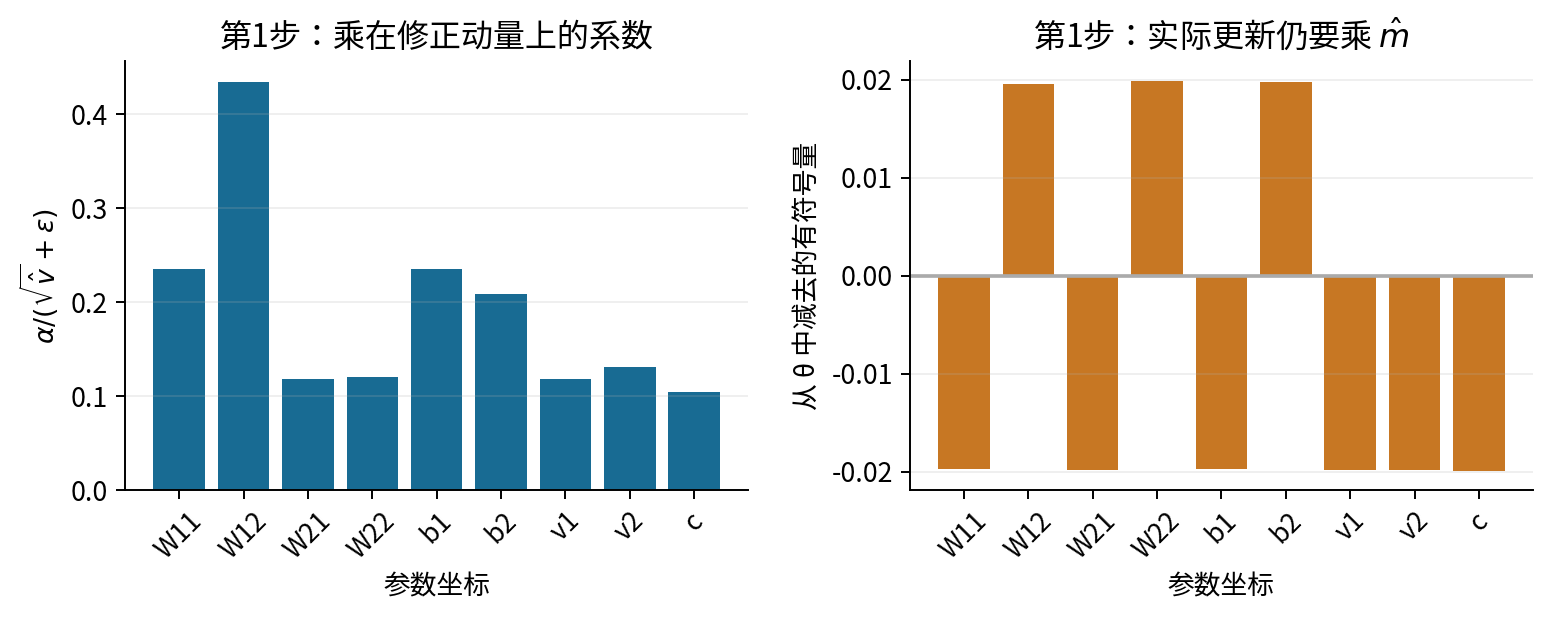

In [7]:
from IPython.display import display, Image
display(Image(filename=str(ROOT / "figures/03_coordinate_steps.png")))

## epsilon与L2/AdamW机制
二维梯度是人为给定序列，用来隔离更新机制，不是同一网络的梯度。pure_decay必须具备零初始状态；none_vs_zero则故意先有一次非零梯度。

In [8]:
mechanisms = e.mechanisms()
print("epsilon", mechanisms["epsilon"])
for family, steps in mechanisms["decay_comparison"].items():
    print(family)
    for step in steps:
        print(e.clean(step))
print("delayed nonzero gradient", mechanisms["delayed_gradient"])

epsilon [{'gradient': 0.0, 'eps_outside_sqrt': 1e-08, 'normalized_update': 0.0, 'wrong_inside_sqrt': 0.0}, {'gradient': 0.0, 'eps_outside_sqrt': 0.001, 'normalized_update': 0.0, 'wrong_inside_sqrt': 0.0}, {'gradient': 1e-12, 'eps_outside_sqrt': 1e-08, 'normalized_update': 9.999000099990002e-05, 'wrong_inside_sqrt': 9.999999999999999e-09}, {'gradient': 1e-12, 'eps_outside_sqrt': 0.001, 'normalized_update': 9.99999999e-10, 'wrong_inside_sqrt': 3.1622776601683794e-11}, {'gradient': 1e-08, 'eps_outside_sqrt': 1e-08, 'normalized_update': 0.5, 'wrong_inside_sqrt': 9.999999950000001e-05}, {'gradient': 1e-08, 'eps_outside_sqrt': 0.001, 'normalized_update': 9.99990000099999e-06, 'wrong_inside_sqrt': 3.1622776601682214e-07}, {'gradient': 0.0001, 'eps_outside_sqrt': 1e-08, 'normalized_update': 0.9999000099990002, 'wrong_inside_sqrt': 0.7071067811865476}, {'gradient': 0.0001, 'eps_outside_sqrt': 0.001, 'normalized_update': 0.09090909090909091, 'wrong_inside_sqrt': 0.003162261848898663}, {'gradient

In [9]:
print("None vs zero", mechanisms["none_vs_zero"])
for case in mechanisms["pure_decay"]:
    print(case["case"], "final", case["path"][-1], "product", case["product"])
print("parameter decay mask", cfg["decay_mask"])

None vs zero {'none': {'before': 0.8809900990099009, 'after': 0.8809900990099009, 'step_before': 1, 'step_after': 1, 'm_before': 0.5, 'm_after': 0.5, 'v_before': 0.5, 'v_after': 0.5}, 'zero': {'before': 0.8809900990099009, 'after': 0.8066182444949799, 'step_before': 1, 'step_after': 2, 'm_before': 0.5, 'm_after': 0.25, 'v_before': 0.5, 'v_after': 0.25}}
constant final 1.3352159435101885 product 1.3352159435101885
lower_lr final 1.9215019140526859 product 1.9215019140526859
half_then_half final 1.6017552844078553 product 1.6017552844078553
parameter decay mask [1, 1, 1, 1, 0, 0, 1, 1, 0]


## 实际重跑全部81候选
下格计算八份确定性产物并写入临时目录。每家族9配置×3训练顺序，各96步、768样本呈现；选择完成后才评价测试。另9次已选轨迹重放计入额外诊断成本。

In [10]:
temporary_run = tempfile.TemporaryDirectory(prefix="dl034-notebook-")
new_outputs = Path(temporary_run.name)
payloads = e.run()
e.write_payloads(payloads, new_outputs)
for name, content in payloads.items():
    if content != (ROOT / "outputs" / name).read_bytes():
        raise ArithmeticError("Recomputed output differs: " + name)
print("All", len(payloads), "fresh results match the supplied bytes")

All 8 fresh results match the supplied bytes


In [11]:
rows = list(csv.DictReader(io.StringIO(payloads["search-grid.csv"].decode())))
print("all search rows", len(rows))
for family in e.FAMILIES:
    family_rows = [r for r in rows if r["family"] == family]
    print(family, "runs", len(family_rows), "steps", sum(int(r["optimizer_steps"]) for r in family_rows), "examples", sum(int(r["training_examples"]) for r in family_rows))
selection = json.loads(payloads["selection.json"])
for row in selection["all_candidates"]:
    print(row)
print("selected", selection["selected"])

all search rows 81
sgd_momentum runs 27 steps 2592 examples 20736
adam runs 27 steps 2592 examples 20736
adamw runs 27 steps 2592 examples 20736
{'family': 'sgd_momentum', 'grid_index': 0, 'lr': 0.01, 'max_seed_validation': 0.025485862466932237, 'mean_validation_half_mse': 0.02537850826486349, 'min_seed_validation': 0.02529400893664627, 'weight_decay': 0.0}
{'family': 'sgd_momentum', 'grid_index': 1, 'lr': 0.01, 'max_seed_validation': 0.027936445552758996, 'mean_validation_half_mse': 0.02783106362689423, 'min_seed_validation': 0.027744979935044725, 'weight_decay': 0.01}
{'family': 'sgd_momentum', 'grid_index': 2, 'lr': 0.01, 'max_seed_validation': 0.059361913540290495, 'mean_validation_half_mse': 0.059216911247155994, 'min_seed_validation': 0.05911616233493816, 'weight_decay': 0.1}
{'family': 'sgd_momentum', 'grid_index': 3, 'lr': 0.03, 'max_seed_validation': 0.019163717609820097, 'mean_validation_half_mse': 0.018919500578885706, 'min_seed_validation': 0.018648093464858448, 'weight_dec

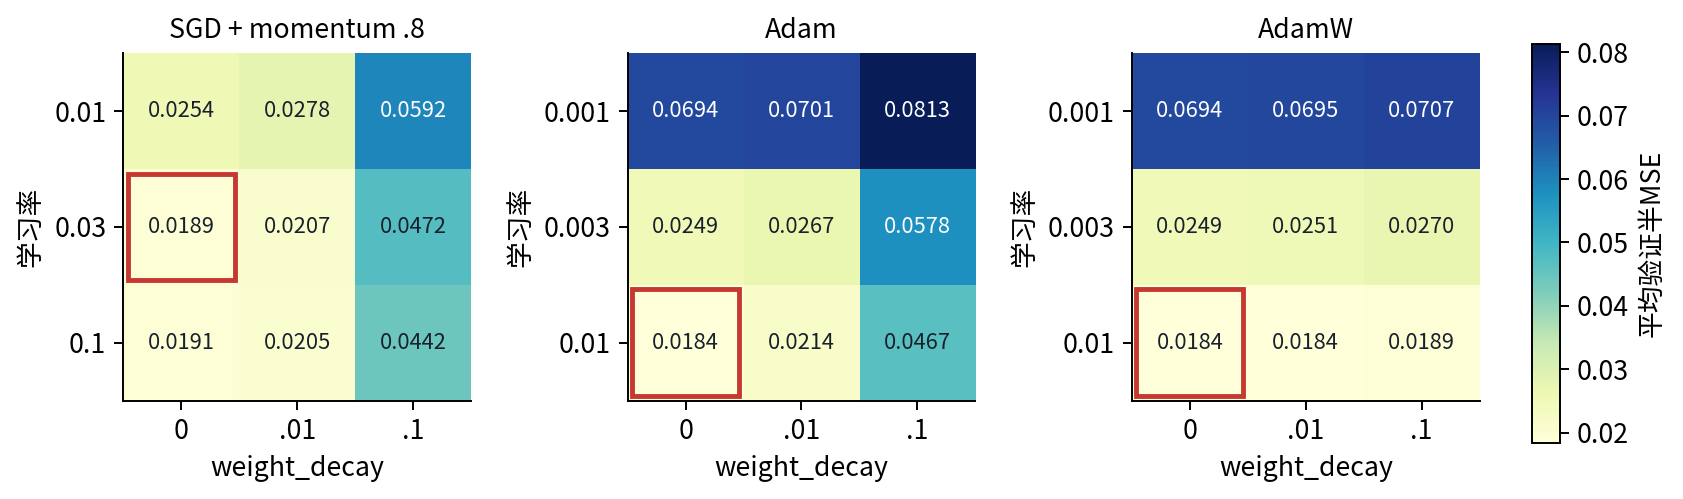

Red cells use mean final validation loss, not test loss


In [12]:
display(Image(filename=str(ROOT / "figures/07_search_grid.png")))
print("Red cells use mean final validation loss, not test loss")

## 冻结后的测试与状态
同一个测试拆分上三种重排seed不是三个独立人群。两个Adam家族选中lambda0后自然相同，不能写成一般等价。

{'family_means': {'adam': 0.01082883266041576, 'adamw': 0.01082883266041576, 'sgd_momentum': 0.011159442021543503}, 'interpretation': 'descriptive on one held-out synthetic split; training seeds are not independent sampled datasets', 'rows': [{'family': 'sgd_momentum', 'grid_index': 3, 'lr': 0.03, 'seed': 340, 'test_half_mse': 0.010957987260062944, 'weight_decay': 0.0}, {'family': 'sgd_momentum', 'grid_index': 3, 'lr': 0.03, 'seed': 341, 'test_half_mse': 0.011306134885182095, 'weight_decay': 0.0}, {'family': 'sgd_momentum', 'grid_index': 3, 'lr': 0.03, 'seed': 342, 'test_half_mse': 0.011214203919385476, 'weight_decay': 0.0}, {'family': 'adam', 'grid_index': 6, 'lr': 0.01, 'seed': 340, 'test_half_mse': 0.010156547368642674, 'weight_decay': 0.0}, {'family': 'adam', 'grid_index': 6, 'lr': 0.01, 'seed': 341, 'test_half_mse': 0.011069047971236947, 'weight_decay': 0.0}, {'family': 'adam', 'grid_index': 6, 'lr': 0.01, 'seed': 342, 'test_half_mse': 0.011260902641367657, 'weight_decay': 0.0}, {

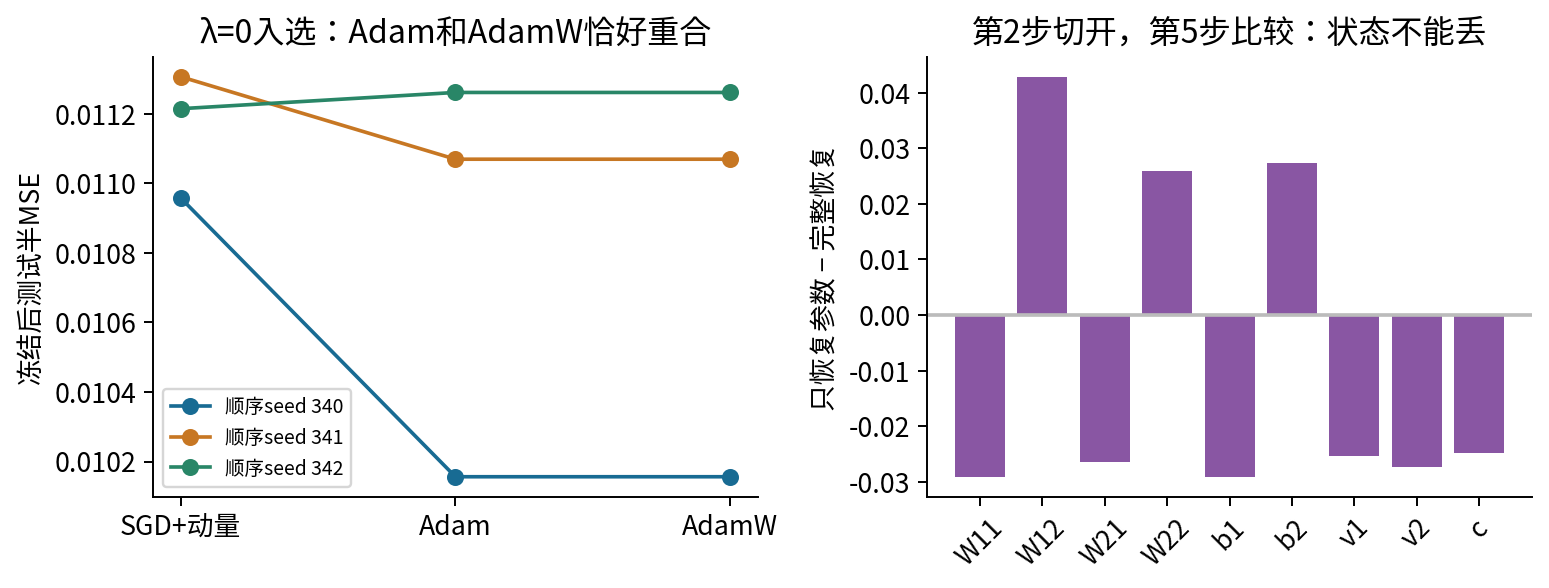

In [13]:
test_report = json.loads(payloads["test-report.json"])
assert test_report["selection_sha256"] == hashlib.sha256(e.canonical(selection)).hexdigest()
print(test_report)
print("resume check", json.loads(payloads["state-check.json"]))
display(Image(filename=str(ROOT / "figures/09_test_and_state.png")))

## 独立参考测试
包括100个独立标量网络、两步18坐标有限差分、75位Decimal的90条七步Adam序列、全部81候选重建和9条选中轨迹每步比对。测试不同于真实任务性能评估。

In [14]:
import unittest
import test_experiment
suite = unittest.defaultTestLoader.loadTestsFromModule(test_experiment)
result = unittest.TextTestRunner(verbosity=1).run(suite)
if not result.wasSuccessful():
    raise RuntimeError("Independent reference tests failed")
print("tests run", result.testsRun)

.

.

.

.

.

...

.

.

.

----------------------------------------------------------------------
Ran 15 tests in 7.516s

OK


tests run 15


## 写下限制再结束
列出：固定初值、一个合成拆分、只有重排种子、有限网格且Adam赢家在上边界；未做时间比较、GPU或跨版本恢复。不要把损失小数差写成显著或普遍优势。

In [15]:
print(json.loads(payloads["summary.json"]))
temporary_run.cleanup()
print("Finished in a clean sequential kernel; original data/report files were not overwritten")

{'additional_diagnostic_replays': 9, 'candidate_configurations_per_family': 9, 'examples_per_run': 768, 'hand_after_two_steps_loss': 4.514479977940921e-05, 'hand_initial_loss': 0.02209999999999999, 'no_time_or_compute_equivalence_claim': True, 'runtime': {'device': 'cpu', 'dtype': 'float64', 'numpy': '2.3.5', 'python': '3.12.14', 'threads': 1, 'torch': '2.7.1+cpu'}, 'search_examples_per_family': 20736, 'search_runs': 81, 'search_steps_per_family': 2592, 'selected': [{'family': 'sgd_momentum', 'grid_index': 3, 'lr': 0.03, 'max_seed_validation': 0.019163717609820097, 'mean_validation_half_mse': 0.018919500578885706, 'min_seed_validation': 0.018648093464858448, 'weight_decay': 0.0}, {'family': 'adam', 'grid_index': 6, 'lr': 0.01, 'max_seed_validation': 0.01862668470259363, 'mean_validation_half_mse': 0.018355545955238087, 'min_seed_validation': 0.01801622940222209, 'weight_decay': 0.0}, {'family': 'adamw', 'grid_index': 6, 'lr': 0.01, 'max_seed_validation': 0.01862668470259363, 'mean_vali